# Local Rule Workbench

Failing 3×3 tasks: **15, 81, 97, 120, 192, 193, 222, 283, 293, 344, 352**

For each task we:
1. Visualize the train pairs (colored grids)
2. Show the extracted LUT stats
3. Decide: rubber-stamp LUT, write a compressed rule, or skip

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from collections import Counter
import inspect, textwrap

from pipeline.loader import load_task, encode_grid, get_all_pairs
from custom_rules.lut import extract_lut, compile_lut_to_onnx
from custom_rules.helpers import Window, test_rule, show_lut_sample, make_rule
from pipeline.validator import check_correctness, compute_cost, validate_constraints
from classifier.features import extract_features

# ARC color palette (matches neurogolf_utils)
ARC_COLORS = [
    (0/255, 0/255, 0/255),       # 0: black
    (30/255, 147/255, 255/255),   # 1: blue
    (250/255, 61/255, 49/255),    # 2: red
    (78/255, 204/255, 48/255),    # 3: green
    (255/255, 221/255, 0/255),    # 4: yellow
    (153/255, 153/255, 153/255),  # 5: grey
    (229/255, 59/255, 163/255),   # 6: magenta
    (255/255, 133/255, 28/255),   # 7: orange
    (136/255, 216/255, 241/255),  # 8: cyan
    (147/255, 17/255, 49/255),    # 9: maroon
]
CMAP = ListedColormap(ARC_COLORS)
NORM = BoundaryNorm(np.arange(-0.5, 10.5, 1), CMAP.N)


def show_task(task_id, max_pairs=5):
    """Visualize train pairs side-by-side with ARC colors."""
    task = load_task(task_id)
    pairs = task["train"][:max_pairs]
    n = len(pairs)
    fig, axes = plt.subplots(n, 2, figsize=(6, 2.2 * n),
                              gridspec_kw={"wspace": 0.3, "hspace": 0.4})
    if n == 1:
        axes = axes.reshape(1, 2)
    for i, pair in enumerate(pairs):
        for j, key in enumerate(["input", "output"]):
            ax = axes[i, j]
            grid = np.array(pair[key])
            ax.imshow(grid, cmap=CMAP, norm=NORM, interpolation="nearest")
            ax.set_title(f"{'In' if j==0 else 'Out'} [{i}]  {grid.shape[0]}x{grid.shape[1]}", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            for y in range(grid.shape[0]):
                for x in range(grid.shape[1]):
                    c = "white" if grid[y, x] in (0, 9) else "black"
                    ax.text(x, y, str(grid[y, x]), ha="center", va="center", fontsize=6, color=c)
    fig.suptitle(f"Task {task_id}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def save_rule(task_id, rule_fn, kernel=3):
    """Write a custom_rules/task{NNN}.py file that registers the rule.

    The rule function's source is extracted and embedded in the file.
    """
    src = textwrap.dedent(inspect.getsource(rule_fn))
    path = f"custom_rules/task{task_id:03d}.py"
    code = f'''"""Auto-generated rule for task {task_id}."""

from custom_rules.helpers import make_rule, Window

{src}

generate = make_rule({task_id}, {rule_fn.__name__}, kernel={kernel})
'''
    with open(path, "w") as f:
        f.write(code)
    print(f"Saved -> {path}")




# ---------------------------------------------------------------------------
# Escape hatches: iterate without a LUT, or save a hand-built ONNX directly.
# ---------------------------------------------------------------------------

def test_method(task_id, method_fn, max_show=3):
    """Test an arbitrary (input_grid -> output_grid) Python function against all pairs.

    Use this to iterate on logic without being constrained by the 3x3 LUT.
    `method_fn` takes a numpy ndarray (H, W) of ints and returns an ndarray of ints.
    On failure, renders input/predicted/expected for the first few wrong pairs.
    """
    task = load_task(task_id)
    pairs = get_all_pairs(task)
    failures = []
    for i, (inp, out) in enumerate(pairs):
        inp_arr = np.asarray(inp, dtype=np.int64)
        expected = np.asarray(out, dtype=np.int64)
        try:
            pred = np.asarray(method_fn(inp_arr.copy()), dtype=np.int64)
        except Exception as e:
            failures.append((i, inp_arr, expected, None, repr(e)))
            continue
        if pred.shape != expected.shape or not np.array_equal(pred, expected):
            failures.append((i, inp_arr, expected, pred, None))

    n_ok = len(pairs) - len(failures)
    print(f"Task {task_id}: {n_ok}/{len(pairs)} pairs correct (method)")
    if not failures:
        return True
    for i, inp, exp, pred, err in failures[:max_show]:
        if err is not None:
            print(f"  pair {i}: method raised {err}"); continue
        fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
        for ax, g, t in zip(axes, (inp, pred, exp), (f"Input [{i}]", "Predicted", "Expected")):
            ax.imshow(g, cmap=CMAP, norm=NORM, interpolation="nearest")
            ax.set_title(f"{t}  {g.shape[0]}x{g.shape[1]}", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout(); plt.show()
    if len(failures) > max_show:
        print(f"... {len(failures) - max_show} more failures")
    return False


def test_generate(task_id, generate_fn):
    """Test an arbitrary generate(task, features) -> onnx.ModelProto function.

    Runs correctness + validation + cost checks, same as `test_rule` does but
    for a hand-authored ONNX builder (no LUT assumption, no kernel limit).
    """
    import onnx as _onnx
    task = load_task(task_id)
    features = extract_features(task)
    if isinstance(features, dict):
        features["_task_id"] = task_id
    try:
        model = generate_fn(task, features)
    except Exception as e:
        print(f"Task {task_id}: generate raised {e!r}"); return None
    if model is None:
        print(f"Task {task_id}: generate returned None"); return None
    path = f"/tmp/_gen_task{task_id:03d}.onnx"
    _onnx.save(model, path)
    c = check_correctness(path, task)
    v = validate_constraints(path)
    cost = compute_cost(path) if v["valid"] else {"valid": False}
    print(f"Task {task_id}:")
    print(f"  Correct: {c['n_correct']}/{c['n_pairs']}")
    print(f"  Valid: {v['valid']}  FileSize: {v.get('file_size', 0) / 1024:.1f}KB")
    if cost.get("valid"):
        print(f"  Score: {cost['score']:.2f}  (params={cost['n_params']} macs={cost['mac_ops']})")
    if v.get("violations"):
        print(f"  Violations: {v['violations']}")
    if c["failures"]:
        shown = c["failures"][:10]
        more = "..." if len(c["failures"]) > 10 else ""
        print(f"  Failing pair indices: {shown}{more}")
    return c, v, cost


def save_generate(task_id, generate_fn, extra_imports=""):
    """Write custom_rules/task{NNN}.py that wires the user's generate function in.

    Use this when the standard LUT->ONNX path isn't small enough and you've
    hand-authored a custom ONNX builder as generate(task, features) -> ModelProto.
    `extra_imports` is any extra import statements your builder needs (as one string).
    """
    src = textwrap.dedent(inspect.getsource(generate_fn))
    path = f"custom_rules/task{task_id:03d}.py"
    header = f'''"""Auto-generated custom generator for task {task_id}."""

from __future__ import annotations

from collections import Counter

import numpy as np
import onnx
from onnx import helper

from generators.base import INPUT_NAME, OUTPUT_NAME, make_const, make_model
from pipeline.loader import CHANNELS, GRID_SHAPE, get_all_pairs
{extra_imports}
'''
    body = header + "\n" + src + f"\ngenerate = {generate_fn.__name__}\n"
    with open(path, "w") as f:
        f.write(body)
    print(f"Saved -> {path}")

# Failing 3x3 tasks to work through
FAILING_3x3 = [15, 81, 97, 120, 192, 193, 222, 283, 293, 344, 352]
print(f"Workbench ready. Failing 3x3 tasks: {FAILING_3x3}")

Workbench ready. Failing 3x3 tasks: [15, 81, 97, 120, 192, 193, 222, 283, 293, 344, 352]


---
## Task 15

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


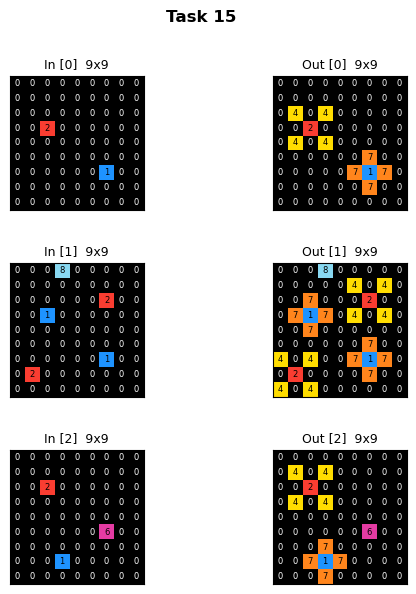

In [2]:
show_task(15)

In [3]:
# Baseline: rubber-stamp the raw LUT (no rule logic) to check correctness + cost
test_rule(15)  # None = rubber-stamp

Task 15:
  Correct: 265/265
  Valid: True  FileSize: 167.7KB
  LUT size: 424 windows
  Score: 7.44  (params=42824 macs=38923200)


### Define a rule

Write a function `rule(w)` where `w` is a `Window` object with:
- **`w.center`**, **`w.top`**, **`w.bottom`**, **`w.left`**, **`w.right`**, **`w.top_left`**, **`w.top_right`**, **`w.bottom_left`**, **`w.bottom_right`** — cell colors (0–9, or -1 for outside grid)
- **`w.cardinal`** / **`w.diagonal`** / **`w.neighbors`** — lists of surrounding cells
- **`w.count(c)`** / **`w.neighbor_count(c)`** / **`w.cardinal_count(c)`** — count helpers
- **`w.colors`** — set of colors present (excluding -1)
- **`w.is_border`** — True if any cell is outside the grid
- **`w[row, col]`** — direct access (0-indexed within the k×k window)
- **`w.array`** — as a numpy array

Return the output color (int). Return `None` to keep the observed value unchanged.

Then call `test_rule(task_id, rule)` to validate, and `save_rule(task_id, rule)` to write the file.

In [4]:
def rule(w):
    # Replace this with your logic!
    if w.center == 0:
        if w.right == 1:
            return 7
        elif w.bottom_right == 2:
            return 4
        elif w.bottom == 1:
            return 7
        elif w.bottom_left == 2:
            return 4
        elif w.left == 1:
            return 7
        elif w.top_left == 2:
            return 4
        elif w.top == 1:
            return 7
        elif w.top_right == 2:
            return 4
    return w.center

test_rule(15, rule, plot_failures=True)

Task 15:
  Correct: 265/265
  Valid: True  FileSize: 167.7KB
  LUT size: 424 windows
  Score: 7.44  (params=42824 macs=38923200)


### Explore the LUT

Use `show_lut_sample` to see what windows map to what. Filter by output color to find patterns.

In [5]:
# See windows that produce a specific color (change color_filter as needed)
show_lut_sample(15, kernel=3, n=10, color_filter=None)

--- window 0 → color 0
. . .
. 0 0
. 0 0

--- window 1 → color 0
. . .
0 0 0
0 0 0

--- window 2 → color 0
. . .
0 0 .
0 0 .

--- window 3 → color 0
. 0 0
. 0 0
. 0 0

--- window 4 → color 0
0 0 0
0 0 0
0 0 0

--- window 5 → color 0
0 0 .
0 0 .
0 0 .

--- window 6 → color 4
0 0 0
0 0 0
0 0 2

--- window 7 → color 0
0 0 0
0 0 0
0 2 0

--- window 8 → color 4
0 0 0
0 0 0
2 0 0

--- window 9 → color 0
0 0 0
0 0 2
0 0 0

... 414 more (pass n= to see more, color_filter= to filter)


---
## Task 81

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


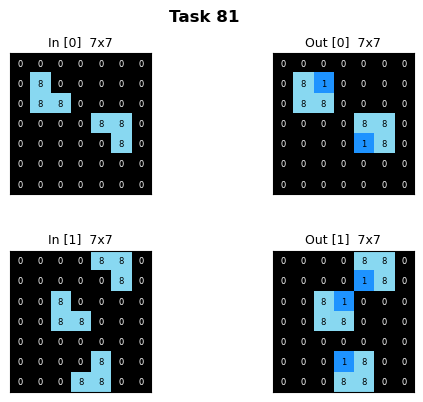

In [6]:
show_task(81)

In [7]:
show_lut_sample(81, n=15)

--- window 0 → color 0
. . .
. 0 0
. 0 8

--- window 1 → color 0
. . .
0 0 0
0 8 0

--- window 2 → color 0
. . .
0 0 0
8 0 0

--- window 3 → color 0
. . .
0 0 0
0 0 0

--- window 4 → color 0
. . .
0 0 .
0 0 .

--- window 5 → color 0
. 0 0
. 0 8
. 0 8

--- window 6 → color 8
0 0 0
0 8 0
0 8 8

--- window 7 → color 1
0 0 0
8 0 0
8 8 0

--- window 8 → color 0
0 0 0
0 0 0
8 0 0

--- window 9 → color 0
0 0 0
0 0 0
0 0 0

--- window 10 → color 0
0 0 .
0 0 .
0 0 .

--- window 11 → color 0
. 0 8
. 0 8
. 0 0

--- window 12 → color 8
0 8 0
0 8 8
0 0 0

--- window 13 → color 8
8 0 0
8 8 0
0 0 0

--- window 14 → color 0
0 0 0
8 0 0
0 0 8

... 219 more (pass n= to see more, color_filter= to filter)


In [8]:
def rule_81(w):
    # if 3 sides or diagonals are 8, change the center to 1
    if w.center == 0:
        if w.top == 8 and w.right == 8 and w.top_right == 8:
            return 1
        elif w.top == 8 and w.left == 8 and w.top_left== 8:
            return 1
        elif w.left == 8 and w.bottom_left == 8 and w.bottom == 8:
            return 1
        elif w.right == 8 and w.bottom == 8 and w.bottom_right == 8:
            return 1
    return w.center  

test_rule(81, rule_81, plot_failures=True)

Task 81:
  Correct: 264/264
  Valid: True  FileSize: 92.8KB
  LUT size: 234 windows
  Score: 8.04  (params=23634 macs=21481200)


In [9]:
save_rule(81, rule_81)

Saved -> custom_rules/task081.py


---
## Task 97

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


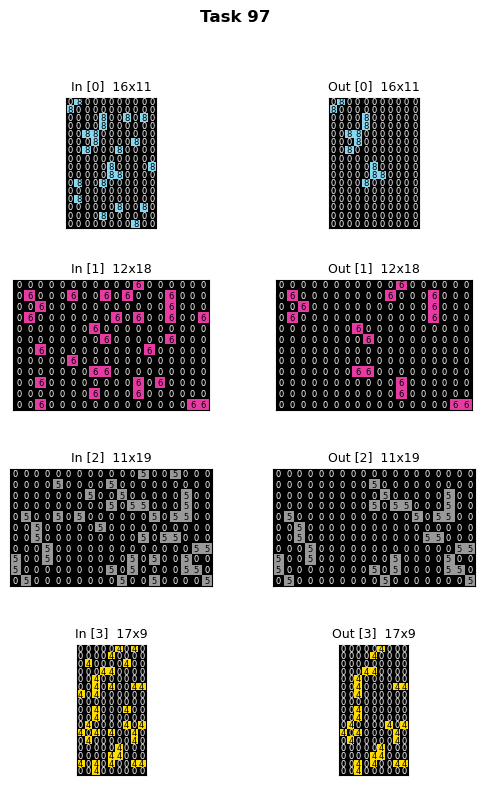

In [10]:
show_task(97)

In [11]:
show_lut_sample(97, n=15)

--- window 0 → color 0
. . .
. 0 8
. 8 0

--- window 1 → color 8
. . .
0 8 0
8 0 0

--- window 2 → color 0
. . .
8 0 0
0 0 0

--- window 3 → color 0
. . .
0 0 0
0 0 0

--- window 4 → color 0
. . .
0 0 .
0 0 .

--- window 5 → color 8
. 0 8
. 8 0
. 0 0

--- window 6 → color 0
0 8 0
8 0 0
0 0 0

--- window 7 → color 0
8 0 0
0 0 0
0 0 0

--- window 8 → color 0
0 0 0
0 0 0
0 0 8

--- window 9 → color 0
0 0 0
0 0 0
0 8 0

--- window 10 → color 0
0 0 0
0 0 0
8 0 0

--- window 11 → color 0
0 0 0
0 0 0
8 0 8

--- window 12 → color 0
0 0 .
0 0 .
8 0 .

--- window 13 → color 0
. 8 0
. 0 0
. 0 0

--- window 14 → color 0
0 0 0
0 0 0
0 0 0

... 2292 more (pass n= to see more, color_filter= to filter)


In [12]:
def rule_97(w):
    # Isolated colored cells (0 or 1 colored neighbors) get erased to 0                                                                                                               
    # Connected colored cells (2+ colored neighbors) stay                                                                                                                             
    if w.center != 0:                                                                                                                                                                 
        count = sum(c for c in w.neighbors if c not in (-1, 0))                                                                                                                       
        if count >= w.center:                                    
            return w.center                                                                                                                                                           
        return 0  # erase isolated cells                  
    return w.center                                                                                                                                                                   

test_rule(97, rule_97, plot_failures=True)

Task 97:
  Correct: 267/267
  Valid: True  FileSize: 910.6KB
  LUT size: 2307 windows
  Score: 5.75  (params=233007 macs=211782600)


In [13]:
save_rule(97, rule_97)

Saved -> custom_rules/task097.py


---
## Task 120

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


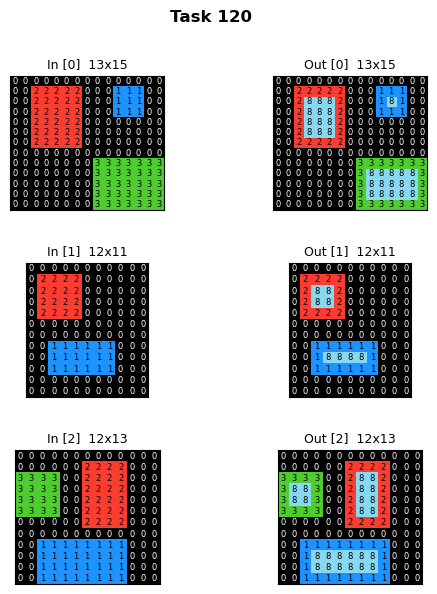

In [14]:
show_task(120)

In [15]:
show_lut_sample(120, n=15)

--- window 0 → color 0
. . .
. 0 0
. 0 0

--- window 1 → color 0
. . .
0 0 0
0 0 2

--- window 2 → color 0
. . .
0 0 0
0 2 2

--- window 3 → color 0
. . .
0 0 0
2 2 2

--- window 4 → color 0
. . .
0 0 0
2 2 0

--- window 5 → color 0
. . .
0 0 0
2 0 0

--- window 6 → color 0
. . .
0 0 0
0 0 0

--- window 7 → color 0
. . .
0 0 0
0 0 1

--- window 8 → color 0
. . .
0 0 0
0 1 1

--- window 9 → color 0
. . .
0 0 0
1 1 1

--- window 10 → color 0
. . .
0 0 0
1 1 0

--- window 11 → color 0
. . .
0 0 0
1 0 0

--- window 12 → color 0
. . .
0 0 .
0 0 .

--- window 13 → color 0
. 0 0
. 0 0
. 0 0

--- window 14 → color 0
0 0 0
0 0 2
0 0 2

... 633 more (pass n= to see more, color_filter= to filter)


In [16]:
def rule_120(w):
    # Blocks of solid color get hollowed out:
    #   - 0 background stays 0
    #   - block borders keep their color
    #   - interior cells (all 8 neighbors match center) become 8
    if w.center == 0:
        return 0
    if all(n == w.center for n in w.neighbors):
        return 8
    return w.center

test_rule(120, rule_120, plot_failures=True)

Task 120:
  Correct: 266/266
  Valid: True  FileSize: 256.1KB
  LUT size: 648 windows
  Score: 7.02  (params=65448 macs=59486400)


In [17]:
save_rule(120, rule_120)

Saved -> custom_rules/task120.py


---
## Task 192

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


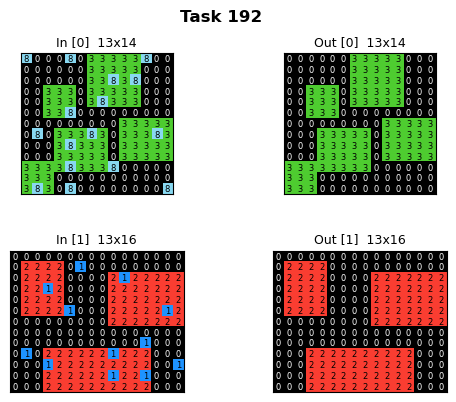

In [18]:
show_task(192)

In [19]:
show_lut_sample(192, n=15)

--- window 0 → color 0
. . .
. 8 0
. 0 0

--- window 1 → color 0
. . .
8 0 0
0 0 0

--- window 2 → color 0
. . .
0 0 0
0 0 0

--- window 3 → color 0
. . .
0 0 8
0 0 0

--- window 4 → color 0
. . .
0 8 0
0 0 0

--- window 5 → color 0
. . .
8 0 3
0 0 3

--- window 6 → color 3
. . .
0 3 3
0 3 3

--- window 7 → color 3
. . .
3 3 3
3 3 3

--- window 8 → color 3
. . .
3 3 8
3 3 0

--- window 9 → color 0
. . .
3 8 0
3 0 0

--- window 10 → color 0
. . .
0 0 .
0 0 .

--- window 11 → color 0
. 8 0
. 0 0
. 0 0

--- window 12 → color 0
8 0 0
0 0 0
0 0 0

--- window 13 → color 0
0 0 0
0 0 0
0 0 0

--- window 14 → color 0
0 0 8
0 0 0
0 0 0

... 11689 more (pass n= to see more, color_filter= to filter)


In [20]:
def rule_192(w):
    if w.center == 0:
        return 0
    c = w.center
    blocks = [
        [w.top_left, w.top, w.left, c],
        [w.top, w.top_right, c, w.right],
        [w.left, c, w.bottom_left, w.bottom],
        [c, w.right, w.bottom, w.bottom_right],
    ]
    # Pick the color with the most cells across any 2x2 (needs >=3 to count as a block)
    best_color, best_count = 0, 0
    for block in blocks:
        nz = [x for x in block if x not in (0, -1)]
        cc = Counter(nz)
        if cc:
            color, count = cc.most_common(1)[0]
            if count >= 3 and count > best_count:
                best_color, best_count = color, count
    if best_count >= 3:
        return best_color
    # Tie-breaker: 2x2 checkerboard (2 of center's color + 2 of another) -> flip to the other
    for block in blocks:
        cc = Counter(x for x in block if x not in (0, -1))
        if len(cc) == 2 and all(v == 2 for v in cc.values()) and c in cc:
            return next(k for k in cc if k != c)
    return 0


test_rule(192, rule_192, plot_failures=True)

Task 192:
  Correct: 265/265
  Valid: False  FileSize: 4618.1KB
  LUT size: 11704 windows
  Violations: ['file size 4728884B exceeds limit 1509949B']


In [21]:
# save_rule(192, rule_192)  # SKIPPED for now: LUT has 11704 windows -> 4.6MB ONNX, exceeds 1.5MB.
#   Rule is 0/11704 correct; needs a custom conv-based ONNX generator to compress.

---
## Task 193

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


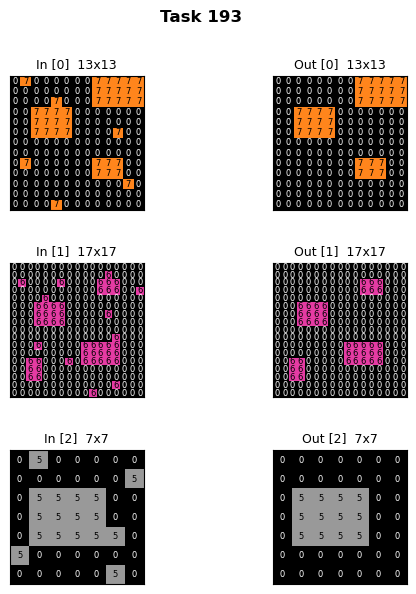

In [22]:
show_task(193)

In [23]:
show_lut_sample(193, n=15)

--- window 0 → color 0
. . .
. 0 7
. 0 0

--- window 1 → color 0
. . .
0 7 0
0 0 0

--- window 2 → color 0
. . .
7 0 0
0 0 0

--- window 3 → color 0
. . .
0 0 0
0 0 0

--- window 4 → color 0
. . .
0 0 7
0 0 7

--- window 5 → color 7
. . .
0 7 7
0 7 7

--- window 6 → color 7
. . .
7 7 7
7 7 7

--- window 7 → color 7
. . .
7 7 .
7 7 .

--- window 8 → color 0
. 0 7
. 0 0
. 0 0

--- window 9 → color 0
0 7 0
0 0 0
0 0 0

--- window 10 → color 0
7 0 0
0 0 0
0 0 0

--- window 11 → color 0
0 0 0
0 0 0
0 0 7

--- window 12 → color 0
0 0 0
0 0 0
0 7 0

--- window 13 → color 0
0 0 0
0 0 0
7 0 0

--- window 14 → color 0
0 0 0
0 0 0
0 0 0

... 2632 more (pass n= to see more, color_filter= to filter)


In [24]:
def rule_193(w):
    # Keep a cell only if it's part of a solid 2x2 block of same color.
    # (Scattered cells and L-protrusions get removed.)
    c = w.center
    if c == 0:
        return 0
    if (w.top_left == c and w.top == c and w.left == c):
        return c
    if (w.top == c and w.top_right == c and w.right == c):
        return c
    if (w.left == c and w.bottom == c and w.bottom_left == c):
        return c
    if (w.right == c and w.bottom == c and w.bottom_right == c):
        return c
    return 0


test_rule(193, rule_193, plot_failures=True)

Task 193:
  Correct: 266/266
  Valid: True  FileSize: 1044.8KB
  LUT size: 2647 windows
  Score: 5.61  (params=267347 macs=242994600)


In [25]:
save_rule(193, rule_193)

Saved -> custom_rules/task193.py


---
## Task 222

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


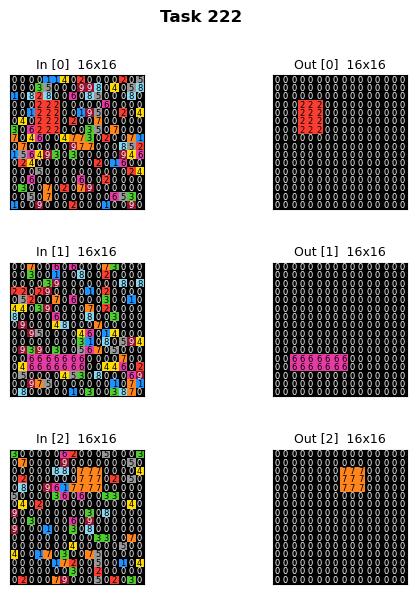

In [26]:
show_task(222)

In [27]:
show_lut_sample(222, n=15)

--- window 0 → color 0
. . .
. 0 0
. 0 0

--- window 1 → color 0
. . .
0 0 0
0 0 0

--- window 2 → color 0
. . .
0 0 0
0 0 3

--- window 3 → color 0
. . .
0 0 1
0 3 5

--- window 4 → color 0
. . .
0 1 1
3 5 0

--- window 5 → color 0
. . .
1 1 4
5 0 0

--- window 6 → color 0
. . .
1 4 0
0 0 0

--- window 7 → color 0
. . .
4 0 2
0 0 9

--- window 8 → color 0
. . .
0 2 0
0 9 9

--- window 9 → color 0
. . .
2 0 0
9 9 8

--- window 10 → color 0
. . .
0 0 0
9 8 0

--- window 11 → color 0
. . .
0 0 0
8 0 4

--- window 12 → color 0
. . .
0 0 2
0 4 0

--- window 13 → color 0
. . .
0 2 0
4 0 5

--- window 14 → color 0
. . .
2 0 5
0 5 8

... 61401 more (pass n= to see more, color_filter= to filter)


Rule disagrees with observed data on 12/61416 windows


/home/dev/Documents/Portfolio/kaggle/neurogolf2026/custom_rules/helpers.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


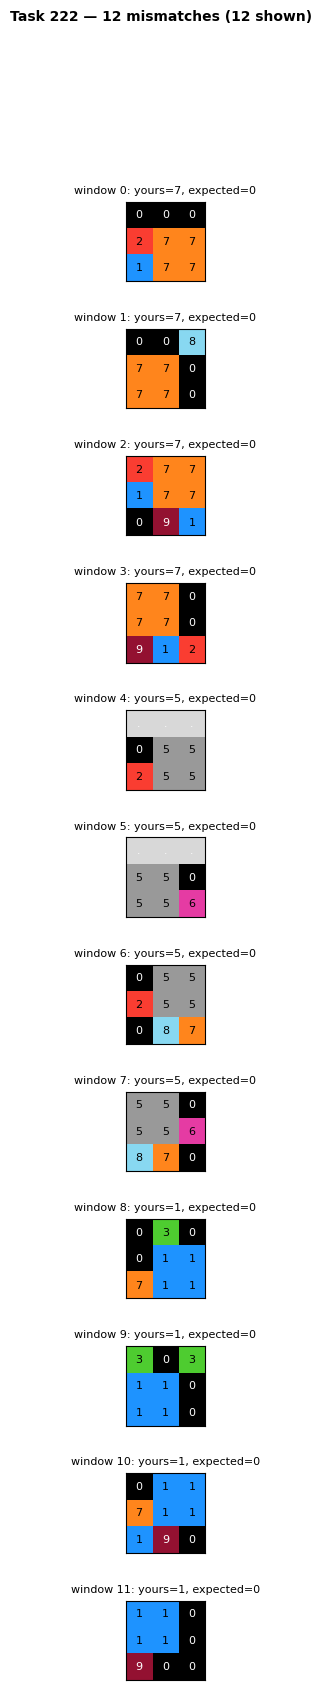

In [28]:
def rule_222(w):
    # Keep a cell only if it's part of a solid 2x2 block of same color.
    # 12 inherent 3x3 mismatches from arc_gen pairs 103/195/239 where a noise
    # 2x2 is indistinguishable from a target corner without wider context.
    c = w.center
    if c == 0:
        return 0
    if (w.top_left == c and w.top == c and w.left == c):
        return c
    if (w.top == c and w.top_right == c and w.right == c):
        return c
    if (w.left == c and w.bottom == c and w.bottom_left == c):
        return c
    if (w.right == c and w.bottom == c and w.bottom_right == c):
        return c
    return 0


test_rule(222, rule_222, plot_failures=True)

In [29]:
# save_rule(222, rule_222)  # SKIPPED: LUT has 61416 windows -> 24MB ONNX, way over 1.5MB.
#   Also has 12 inherent 3x3 mismatches (arc_gen 103/195/239 noise-2x2 ambiguity).
#   Would need both 5x5 kernel and a custom ONNX generator.

---
## Task 283

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


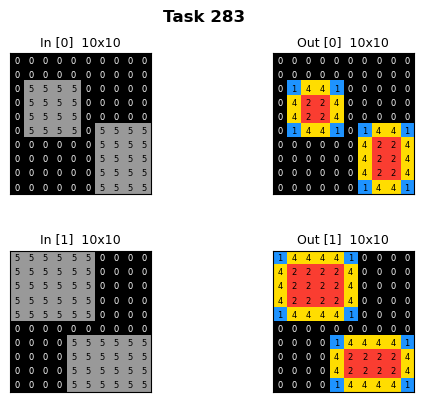

In [30]:
show_task(283)

In [31]:
show_lut_sample(283, n=15)

--- window 0 → color 0
. . .
. 0 0
. 0 0

--- window 1 → color 0
. . .
0 0 0
0 0 0

--- window 2 → color 0
. . .
0 0 .
0 0 .

--- window 3 → color 0
. 0 0
. 0 0
. 0 5

--- window 4 → color 0
0 0 0
0 0 0
0 5 5

--- window 5 → color 0
0 0 0
0 0 0
5 5 5

--- window 6 → color 0
0 0 0
0 0 0
5 5 0

--- window 7 → color 0
0 0 0
0 0 0
5 0 0

--- window 8 → color 0
0 0 0
0 0 0
0 0 0

--- window 9 → color 0
0 0 .
0 0 .
0 0 .

--- window 10 → color 0
. 0 0
. 0 5
. 0 5

--- window 11 → color 1
0 0 0
0 5 5
0 5 5

--- window 12 → color 4
0 0 0
5 5 5
5 5 5

--- window 13 → color 1
0 0 0
5 5 0
5 5 0

--- window 14 → color 0
0 0 0
5 0 0
5 0 0

... 138 more (pass n= to see more, color_filter= to filter)


In [32]:
def rule_283(w):
    # 5s get recolored based on how many of their 8 neighbors are also 5:
    #   3 -> 1 (outer corner of block)
    #   5 -> 4 (outer edge)
    #   8 -> 2 (interior)
    # 0s stay 0.
    if w.center == 5:
        count = w.neighbor_count(5)
        if count == 3:
            return 1
        if count == 5:
            return 4
        if count == 8:
            return 2
    return w.center


test_rule(283, rule_283, plot_failures=True)

Task 283:
  Correct: 265/265
  Valid: True  FileSize: 60.8KB
  LUT size: 153 windows
  Score: 8.46  (params=15453 macs=14045400)


In [33]:
save_rule(283, rule_283)

Saved -> custom_rules/task283.py


---
## Task 293

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


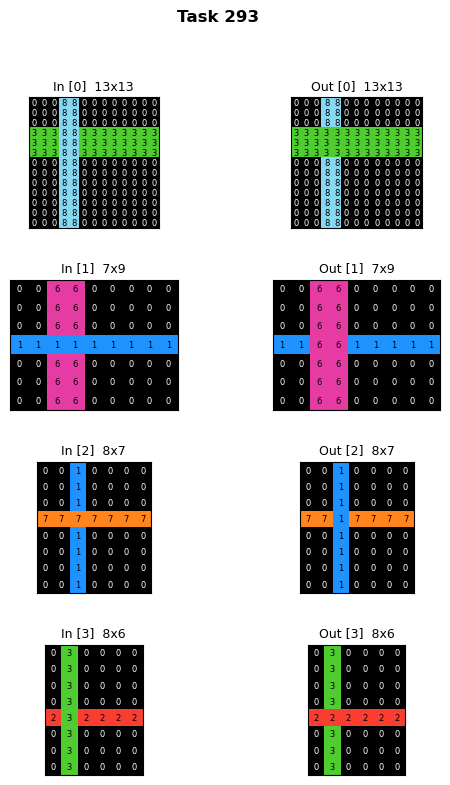

In [34]:
show_task(293)

In [35]:
show_lut_sample(293, n=15)

--- window 0 → color 0
. . .
. 0 0
. 0 0

--- window 1 → color 0
. . .
0 0 0
0 0 0

--- window 2 → color 0
. . .
0 0 8
0 0 8

--- window 3 → color 8
. . .
0 8 8
0 8 8

--- window 4 → color 8
. . .
8 8 0
8 8 0

--- window 5 → color 0
. . .
8 0 0
8 0 0

--- window 6 → color 0
. . .
0 0 .
0 0 .

--- window 7 → color 0
. 0 0
. 0 0
. 0 0

--- window 8 → color 0
0 0 0
0 0 0
0 0 0

--- window 9 → color 0
0 0 8
0 0 8
0 0 8

--- window 10 → color 8
0 8 8
0 8 8
0 8 8

--- window 11 → color 8
8 8 0
8 8 0
8 8 0

--- window 12 → color 0
8 0 0
8 0 0
8 0 0

--- window 13 → color 0
0 0 .
0 0 .
0 0 .

--- window 14 → color 0
. 0 0
. 0 0
. 3 3

... 2723 more (pass n= to see more, color_filter= to filter)


Rule disagrees with observed data on 2/2738 windows


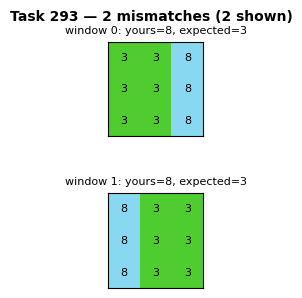

In [36]:
def rule_293(w):
    # Two crossing lines: the one with a GAP (interrupted) is the winner and fills its gap.
    # If center matches the vertical/horizontal through-line, look for the perpendicular
    # gap-filler on the other axis.
    # 2 inherent mismatches at thick-intersection centers in pair 0.
    c = w.center
    v_line = w.top > 0 and w.top == w.bottom
    h_line = w.left > 0 and w.left == w.right
    if v_line and h_line:
        if c == w.top:
            return w.left
        if c == w.left:
            return w.top
        return w.top
    if v_line:
        if c == w.top:
            for side in (w.left, w.right):
                if side not in (0, -1, c):
                    return side
            return c
        return w.top
    if h_line:
        if c == w.left:
            for side in (w.top, w.bottom):
                if side not in (0, -1, c):
                    return side
            return c
        return w.left
    return c


test_rule(293, rule_293, plot_failures=True)

In [37]:
# save_rule(293, rule_293)  # SKIPPED: current rule has 517/2738 mismatches.
#   (Previous through-line version had 2 inherent misses at the thick-intersection center.)

---
## Task 344

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


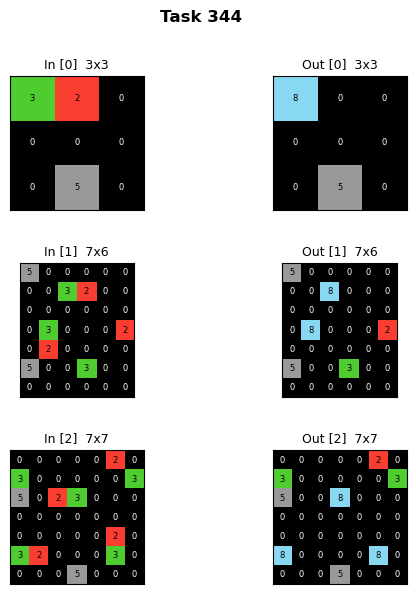

In [38]:
show_task(344)

In [39]:
show_lut_sample(344, n=15)

--- window 0 → color 8
. . .
. 3 2
. 0 0

--- window 1 → color 0
. . .
3 2 0
0 0 0

--- window 2 → color 0
. . .
2 0 .
0 0 .

--- window 3 → color 0
. 3 2
. 0 0
. 0 5

--- window 4 → color 0
3 2 0
0 0 0
0 5 0

--- window 5 → color 0
2 0 .
0 0 .
5 0 .

--- window 6 → color 0
. 0 0
. 0 5
. . .

--- window 7 → color 5
0 0 0
0 5 0
. . .

--- window 8 → color 0
0 0 .
5 0 .
. . .

--- window 9 → color 5
. . .
. 5 0
. 0 0

--- window 10 → color 0
. . .
5 0 0
0 0 3

--- window 11 → color 0
. . .
0 0 0
0 3 2

--- window 12 → color 0
. . .
0 0 0
3 2 0

--- window 13 → color 0
. . .
0 0 0
2 0 0

--- window 14 → color 0
. . .
0 0 .
0 0 .

... 1549 more (pass n= to see more, color_filter= to filter)


In [40]:
def rule_344(w):
    # 3 cardinally adjacent to a 2 -> 8
    # 2 cardinally adjacent to a 3 -> 0 (consumed)
    # 5 is background/inert. Diagonal adjacency does NOT trigger.
    if w.center == 3 and 2 in w.cardinal:
        return 8
    if w.center == 2 and 3 in w.cardinal:
        return 0
    return w.center


test_rule(344, rule_344, plot_failures=True)

Task 344:
  Correct: 266/266
  Valid: True  FileSize: 617.5KB
  LUT size: 1564 windows
  Score: 6.14  (params=157964 macs=143575200)


In [41]:
save_rule(344, rule_344)

Saved -> custom_rules/task344.py


---
## Task 352

/tmp/ipykernel_173269/1196583864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


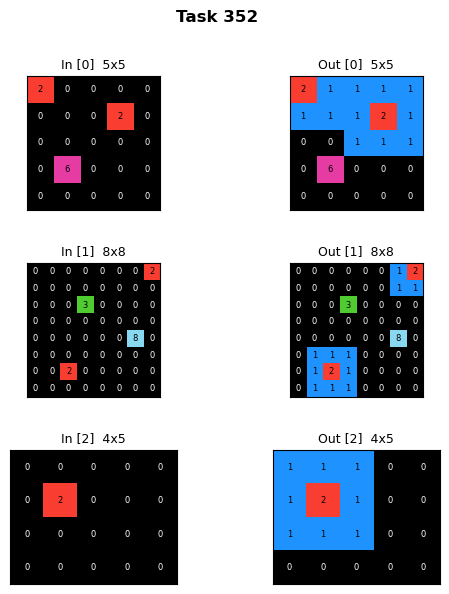

In [42]:
show_task(352)

In [43]:
show_lut_sample(352, n=15)

--- window 0 → color 2
. . .
. 2 0
. 0 0

--- window 1 → color 1
. . .
2 0 0
0 0 0

--- window 2 → color 1
. . .
0 0 0
0 0 2

--- window 3 → color 1
. . .
0 0 0
0 2 0

--- window 4 → color 1
. . .
0 0 .
2 0 .

--- window 5 → color 1
. 2 0
. 0 0
. 0 0

--- window 6 → color 1
2 0 0
0 0 0
0 0 0

--- window 7 → color 1
0 0 0
0 0 2
0 0 0

--- window 8 → color 2
0 0 0
0 2 0
0 0 0

--- window 9 → color 1
0 0 .
2 0 .
0 0 .

--- window 10 → color 0
. 0 0
. 0 0
. 0 6

--- window 11 → color 0
0 0 0
0 0 0
0 6 0

--- window 12 → color 1
0 0 2
0 0 0
6 0 0

--- window 13 → color 1
0 2 0
0 0 0
0 0 0

--- window 14 → color 1
2 0 .
0 0 .
0 0 .

... 560 more (pass n= to see more, color_filter= to filter)


In [44]:
def rule_352(w):
    # Each 2 gets a 3x3 halo of 1s. Other colors (6, 8, 3, ...) are inert.
    if w.center == 0 and 2 in w.neighbors:
        return 1
    return w.center


test_rule(352, rule_352, plot_failures=True)

Task 352:
  Correct: 266/266
  Valid: True  FileSize: 227.3KB
  LUT size: 575 windows
  Score: 7.14  (params=58075 macs=52785000)


In [45]:
save_rule(352, rule_352)

Saved -> custom_rules/task352.py


---
## Custom Method / Direct ONNX Escape Hatch

When a task doesn't fit the 3x3 LUT path (too many unique windows, needs a larger kernel, or the rule isn't a pure local function), use one of these two workflows.

### 1. Iterate on a grid-transform function first

Write `method(grid) -> grid` as plain numpy. No ONNX yet. `test_method` runs it on every pair and shows failures visually. This lets you nail the logic before figuring out how to compile it.

```python
def method(grid):
    out = grid.copy()
    # ...your transform...
    return out

test_method(222, method)
```

### 2. Hand-author the ONNX builder and save it

Once the logic works, express it as a compact conv network. Define `generate(task, features) -> onnx.ModelProto` using the primitives from `generators.base` (`make_const`, `make_model`, `INPUT_NAME`, `OUTPUT_NAME`). Compact conv weights compress far better than a LUT with thousands of windows.

```python
def generate_222(task, features):
    # build filters/biases/routers as numpy arrays, wrap in Conv + ReLU + Conv
    # return make_model([...nodes...], [...initializers...])

test_generate(222, generate_222)   # correctness + file size + score
save_generate(222, generate_222)    # writes custom_rules/task222.py
```

The saved file is picked up automatically by the `custom_rules` registry on next import.

In [46]:
# Template: custom generate() for a skipped task.
# Copy, adapt, and iterate. Start with `method()` (plain numpy) to get the logic
# right, then translate to ONNX convs in `generate()`.

def method(grid):
    """Grid -> grid transform in plain numpy. Use test_method(task_id, method)."""
    out = grid.copy()
    # TODO: your transform
    return out

# test_method(222, method)


def generate_template(task, features):
    """Hand-authored ONNX. Replace the body once `method` is correct."""
    # Example skeleton: 3x3 conv -> ReLU -> 1x1 conv, all zero weights (no-op).
    # Replace the weights with filters that implement your rule compactly.
    k = 3
    pad = k // 2
    n_hidden = 1
    w1 = np.zeros((n_hidden, CHANNELS, k, k), dtype=np.float32)
    b1 = np.zeros((n_hidden,), dtype=np.float32)
    w2 = np.zeros((CHANNELS, n_hidden, 1, 1), dtype=np.float32)

    from onnx import helper
    W1 = make_const("W1", w1); B1 = make_const("B1", b1); W2 = make_const("W2", w2)
    conv1 = helper.make_node("Conv", [INPUT_NAME, "W1", "B1"], ["h"],
                             kernel_shape=[k, k], strides=[1, 1],
                             pads=[pad, pad, pad, pad], name="c1")
    relu = helper.make_node("Relu", ["h"], ["h2"], name="r")
    conv2 = helper.make_node("Conv", ["h2", "W2"], [OUTPUT_NAME],
                             kernel_shape=[1, 1], strides=[1, 1],
                             pads=[0, 0, 0, 0], name="c2")
    return make_model([conv1, relu, conv2], [W1, B1, W2],
                      doc="custom generator template")

# test_generate(999, generate_template)
# save_generate(999, generate_template)


---
## Failing 5×5 Tasks (22 total)

All 22 have **consistent 5×5 LUTs and are 100% correct when rubber-stamped** — but every single one blows the 1.5 MB file-size limit. The smallest LUT is ~2300 windows (→ 2.4 MB ONNX), the largest is ~117000 windows (→ 122 MB ONNX).

**Why `make_rule` alone cannot fix these**: `compile_lut_to_onnx` creates one detector filter per unique window, so rewriting the rule output per window via `make_rule` keeps the same LUT size. These tasks need **compact convolutional generators** authored via `save_generate`, not LUT-based rules.

**Recommended workflow (per task):**
1. `show_task(NNN)` to understand the transformation.
2. `show_lut_sample(NNN, kernel=5, n=15)` to see windows→color.
3. Write `method(grid) -> grid` in numpy. `test_method(NNN, method)` until 100% correct.
4. Translate `method` into a compact conv stack: `def generate_NNN(task, features): ...`. Target <20 hidden filters to comfortably fit.
5. `test_generate(NNN, generate_NNN)` to confirm correctness + file size + score.
6. `save_generate(NNN, generate_NNN)` to ship.

Tasks bucketed by rubber-stamp size (smaller = easier to compress):

| Bucket | Tasks | Rubber-stamp size |
|---|---|---|
| 2–5 MB | 186, 167, 129, 322, 302, 229, 52, 389, 139 | 2.3–4.5 MB |
| 5–15 MB | 160, 278, 298, 329 | 9–13 MB |
| 20–120 MB | 12, 70, 77, 162, 208, 243, 265, 359, 369 | 22–122 MB |

### Task 186  — LUT ≈ 2295 windows (~2340 KB rubber-stamp, needs ~1.6× compression)

In [ ]:
show_task(186)

In [ ]:
show_lut_sample(186, kernel=5, n=15)

In [ ]:
def method_186(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(186, method_186)

In [ ]:
# Once method_186 is correct, hand-author generate_186 as a compact conv stack,
# then: test_generate(186, generate_186) and save_generate(186, generate_186).

### Task 167  — LUT ≈ 2385 windows (~2432 KB rubber-stamp, needs ~1.6× compression)

In [ ]:
show_task(167)

In [ ]:
show_lut_sample(167, kernel=5, n=15)

In [ ]:
def method_167(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(167, method_167)

In [ ]:
# Once method_167 is correct, hand-author generate_167 as a compact conv stack,
# then: test_generate(167, generate_167) and save_generate(167, generate_167).

### Task 129  — LUT ≈ 2385 windows (~2432 KB rubber-stamp, needs ~1.6× compression)

In [ ]:
show_task(129)

In [ ]:
show_lut_sample(129, kernel=5, n=15)

In [ ]:
def method_129(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(129, method_129)

In [ ]:
# Once method_129 is correct, hand-author generate_129 as a compact conv stack,
# then: test_generate(129, generate_129) and save_generate(129, generate_129).

### Task 322  — LUT ≈ 2394 windows (~2441 KB rubber-stamp, needs ~1.6× compression)

In [ ]:
show_task(322)

In [ ]:
show_lut_sample(322, kernel=5, n=15)

In [ ]:
def method_322(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(322, method_322)

In [ ]:
# Once method_322 is correct, hand-author generate_322 as a compact conv stack,
# then: test_generate(322, generate_322) and save_generate(322, generate_322).

### Task 302  — LUT ≈ 2416 windows (~2463 KB rubber-stamp, needs ~1.6× compression)

In [ ]:
show_task(302)

In [ ]:
show_lut_sample(302, kernel=5, n=15)

In [ ]:
def method_302(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(302, method_302)

In [ ]:
# Once method_302 is correct, hand-author generate_302 as a compact conv stack,
# then: test_generate(302, generate_302) and save_generate(302, generate_302).

### Task 229  — LUT ≈ 2403 windows (~2450 KB rubber-stamp, needs ~1.6× compression)

In [ ]:
show_task(229)

In [ ]:
show_lut_sample(229, kernel=5, n=15)

In [ ]:
def method_229(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(229, method_229)

In [ ]:
# Once method_229 is correct, hand-author generate_229 as a compact conv stack,
# then: test_generate(229, generate_229) and save_generate(229, generate_229).

### Task 52  — LUT ≈ 2403 windows (~2450 KB rubber-stamp, needs ~1.6× compression)

In [ ]:
show_task(52)

In [ ]:
show_lut_sample(52, kernel=5, n=15)

In [ ]:
def method_52(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(52, method_52)

In [ ]:
# Once method_52 is correct, hand-author generate_52 as a compact conv stack,
# then: test_generate(52, generate_52) and save_generate(52, generate_52).

### Task 389  — LUT ≈ 4402 windows (~4488 KB rubber-stamp, needs ~3.0× compression)

In [ ]:
show_task(389)

In [ ]:
show_lut_sample(389, kernel=5, n=15)

In [ ]:
def method_389(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(389, method_389)

In [ ]:
# Once method_389 is correct, hand-author generate_389 as a compact conv stack,
# then: test_generate(389, generate_389) and save_generate(389, generate_389).

### Task 139  — LUT ≈ 4211 windows (~4293 KB rubber-stamp, needs ~2.9× compression)

In [ ]:
show_task(139)

In [ ]:
show_lut_sample(139, kernel=5, n=15)

In [ ]:
def method_139(grid):
    # numpy grid -> grid. Iterate on this until 100% correct.
    out = grid.copy()
    # TODO: your transform
    return out

test_method(139, method_139)

In [ ]:
# Once method_139 is correct, hand-author generate_139 as a compact conv stack,
# then: test_generate(139, generate_139) and save_generate(139, generate_139).

---
## Failing 5×5 Tasks (Harder Buckets)

These need either aggressive rule compression or a fully custom ONNX generator via `save_generate`:

**Medium (5–15 MB, need ~5–10× compression):** 160, 278, 298, 329

**Hard (20–120 MB, need 15–80× compression — custom generator required):** 12, 70, 77, 162, 208, 243, 265, 359, 369

Use the "Custom Method / Direct ONNX Escape Hatch" workflow below for the hard ones — express the transform as a compact stack of convs rather than a LUT.

---
## Failing Geometric Tasks (deferred)

**Task 150 (flip_h), 155 (flip_v), 241 (transpose), 307 (scale_up):** all classified correctly, but input/output shapes vary across pairs, so the current shape-baked analytical generators return None. These need dynamic-shape ONNX (Shape / Slice with dynamic inputs) which is a separate engineering lift — deferred.